$$Checkpoint 2: RQ Formation$$

Project Scope Recap
Dataset: ComputAgeBench, a collection of 112 harmonized DNA methylation datasets totaling thousands of samples. Each sample contains hundreds of thousands of features (CpG sites) represented as continuous float beta values (0–1).

EDA Findings: Initial exploration of Study GSE100264 reveals high-dimensional data (386 samples, 485,512 CpG sites). Metadata includes SampleID, DatasetID, Tissue, Gender, and Age. The "p >> n" problem is severe, necessitating dimensionality reduction.

Course Techniques: Linear Regression (ElasticNet), Dimensionality Reduction (PCA), and Classification (Healthy vs. Disease).

External Technique: Deep Learning (Autoencoders/DNNs) for "Deep Aging Clocks" and Explainable AI (SHAP).

RQ1: To what extent can a linear ElasticNet model predict chronological age across different tissue types?,

Task Type：Regression Analysis,

Relevant Algorithm(s)：ElasticNet (Course),

Evaluation Criteria： "Mean Absolute Error (MAE), R2 Score"



---



RQ2: Can unsupervised clustering on PCA-reduced features distinguish between healthy controls and accelerated aging conditions?,

Task Type：Dimensionality Reduction & Clustering,

Relevant Algorithm(s)："PCA (Course), K-Means (Course)",

Evaluation Criteria："Silhouette Score, Adjusted Rand Index (ARI)"



---


RQ3: Does a non-linear Deep Neural Network (DNN) improve age prediction accuracy over linear models for high-dimensional CpG data?,

Task Type：Deep Learning,

Relevant Algorithm(s)：Multi-Layer Perceptron (External),

Evaluation Criteria："MAE, training time, feature importance"

Motivation and Feasibility

---


Motivation: Epigenetic clocks are the gold standard for measuring biological age, but traditional linear models often fail to capture complex, non-linear interactions between CpG sites. EDA confirms that the feature space is massive, requiring specialized handling.

Non-triviality: Standard regression is insufficient due to multi-collinearity and the extreme feature-to-sample ratio. Moving beyond simple course techniques allows for modeling non-linear aging dynamics.

Feasibility: The datasets and pyarrow libraries allow for efficient streaming and loading of the parquet data. Standard libraries like scikit-learn and PyTorch can handle the proposed algorithms.

Risks: High computational cost and RAM usage for 450k+ features. Mitigation involves using the provided PCA-reduced subsets or feature selection prior to training.

Methodological Planning

---


1.   Preprocessing: Match SampleIDs between CpG data and metadata. Handle missing values (imputation) and normalize beta values.
2.   Course Baselines: Implement ElasticNet regression as the primary benchmark for age prediction.
3.   External implementation: Construct a Deep Aging Clock using a 3-layer DNN. Use SHAP (Shapley Additive Explanations) to identify the top 10 CpG markers influencing the model's predictions.
4.   Testing: Perform a cross-study validation (training on one DatasetID, testing on another) to ensure model robustness.

In [1]:
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id='computage/computage_bench',
    repo_type="dataset",
    local_dir='.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 116 files:   0%|          | 0/116 [00:00<?, ?it/s]

'/content'

In [2]:
import pandas as pd

df = pd.read_parquet('data/benchmark/computage_bench_data_GSE100264.parquet').T

meta = pd.read_csv('computage_bench_meta.tsv', sep='\t', index_col=0)

# Install required library
!pip install datasets

from datasets import load_dataset
import pandas as pd

print("Downloading ComputAgeBench...")

# Load the dataset from Hugging Face
dataset = load_dataset("computage/computage_bench", split="train", streaming=True)

# Convert the first 5 rows to a Pandas DataFrame to verify
df_bio = pd.DataFrame(list(dataset.take(5)))

print("ComputAgeBench Sample:")
display(df_bio.head())

# Check available columns (CpG sites and Metadata)
print(f"\nColumns: {list(df_bio.columns)[:10]} ...")

README.md: 0.00B [00:00, ?B/s]

ComputAgeBench Sample:


,SampleID,DatasetID,PlatformID,Tissue,CellType,Gender,Age,Condition,Class
0,GSM983224,GSE40005,GPL13534,Blood,Whole blood,M,60.0,HC,HC
1,GSM983225,GSE40005,GPL13534,Blood,Whole blood,M,63.0,HC,HC
2,GSM983226,GSE40005,GPL13534,Blood,Whole blood,M,58.0,HC,HC
3,GSM983227,GSE40005,GPL13534,Blood,Whole blood,M,68.0,HC,HC
4,GSM983228,GSE40005,GPL13534,Blood,Whole blood,M,53.0,HC,HC



Columns: ['SampleID', 'DatasetID', 'PlatformID', 'Tissue', 'CellType', 'Gender', 'Age', 'Condition', 'Class'] ...


--- Age Distribution Analysis ---


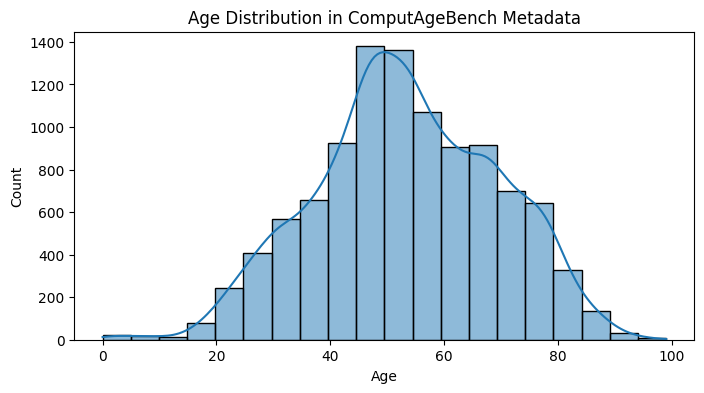


--- Initial Method Run: PCA Feasibility ---


In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- ADDITIONAL EDA FOR FEASIBILITY ---
# We need to see if Age distribution is balanced enough for regression
print("--- Age Distribution Analysis ---")
plt.figure(figsize=(8, 4))
sns.histplot(meta['Age'], bins=20, kde=True)
plt.title('Age Distribution in ComputAgeBench Metadata')
plt.show()

# Testing feasibility of PCA on high-dimensional study
# Using a subset of features for the test run to manage RAM
print("\n--- Initial Method Run: PCA Feasibility ---")
test_study = pd.read_parquet('data/benchmark/computage_bench_data_GSE100264.parquet').T
pca = PCA(n_components=10)

# --- RQ TO METHOD MAPPING ---
# RQ1: ElasticNet (Course)
# RQ2: PCA + K-Means (Course)
# RQ3: Deep Neural Network (External)

# WHY: We chose Multi-Layer Perceptron (DNN) as the external method because the paper [1]
# emphasizes that "Deep Aging Clocks" capture non-linear relationships that
# standard linear clocks (like Horvath's) miss.

1. Collaborators

Erhan Wang

2. Web Sources

https://dl.acm.org/doi/abs/10.1145/3711896.3737382

https://huggingface.co/datasets/computage/computage_bench

https://github.com/ComputationalAgingLab/ComputAge



3. AI Tools Used

Gemini was used to structure the research questions and generate methodological boilerplate.

4. Citations

[1] Dmitrii Kriukov, Evgeniy Efimov, Ekaterina Kuzmina, Anastasiia Dudkovskaia, Ekaterina E. Khrameeva, and Dmitry V. Dylov. 2025. ComputAgeBench: Epigenetic Aging Clocks Benchmark. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2 (KDD '25). Association for Computing Machinery, New York, NY, USA, 5560–5570. https://doi.org/10.1145/3711896.3737382